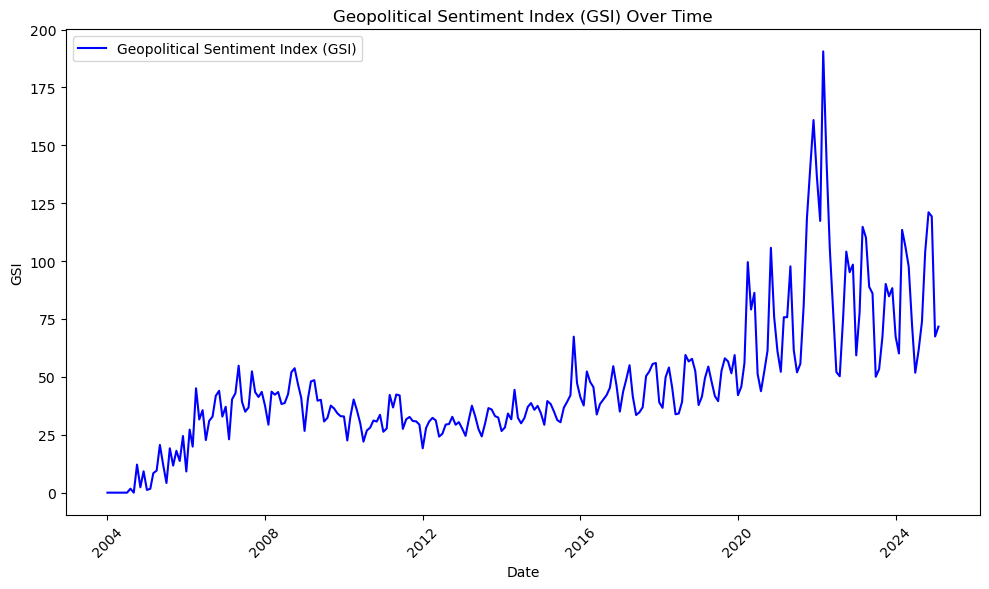

Done


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

def normalize_interest(df, peak_interest):
    df['normalized_interest'] = (df['interest'] / peak_interest) * 100
    return df

def process_data(file_path, peak_dict, measuring_period_start, measuring_period_end):
    df = pd.read_csv(file_path)
    
    df['interest'] = df['interest'].replace('<1', 0).astype(float)
    
    df['date'] = pd.to_datetime(df['date'])
    
    df_measure = df[(df['date'] >= measuring_period_start) & (df['date'] <= measuring_period_end)]
    
    keyword = file_path.split('/')[-1].split('.')[0]
    
    peak_dict[keyword] = df_measure['interest'].max()

    df = normalize_interest(df, peak_dict[keyword])
    
    return df

def calculate_gsi(keywords_df):
    gsi = keywords_df.mean(axis=1)
    return gsi

csv_files = glob.glob("DATA GG TREND VN/*.csv")

peak_dict = {}

measuring_period_start = '2004-01-01'  
measuring_period_end = '2009-12-31'  

keyword_dfs = []
for file in csv_files:
    df = process_data(file, peak_dict, measuring_period_start, measuring_period_end)
    keyword_dfs.append(df[['date', 'normalized_interest']].set_index('date'))

merged_df = pd.concat(keyword_dfs, axis=1)

gsi = calculate_gsi(merged_df)

merged_df['GSI'] = gsi

plt.figure(figsize=(10, 6))
plt.plot(merged_df.index, merged_df['GSI'], label='Geopolitical Sentiment Index (GSI)', color='b')
plt.title('Geopolitical Sentiment Index (GSI) Over Time')
plt.xlabel('Date')
plt.ylabel('GSI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

merged_df.to_excel('test nhó.xlsx')

print("Done")


In [9]:
print(df.columns)

Index(['date', 'interest', 'normalized_interest'], dtype='object')


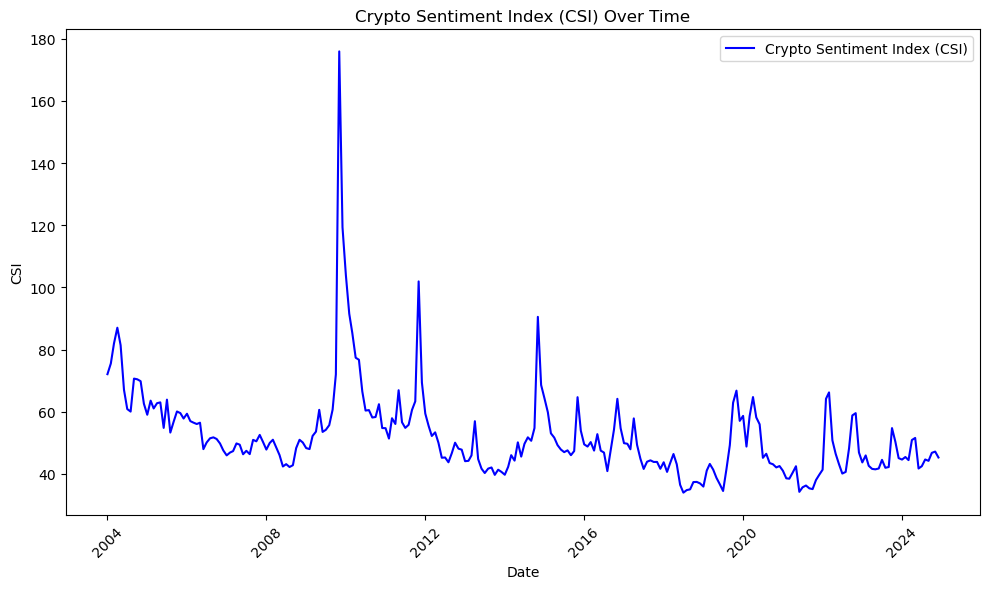

Chỉ số CSI đã được tính và lưu vào 'CSI_result.csv'


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# Hàm chuẩn hóa dữ liệu theo peak interest
def normalize_interest(df, peak_interest):
    df['normalized_interest'] = (df['interest'] / peak_interest) * 100
    return df

# Hàm xử lý dữ liệu từ các file CSV
def process_data(file_path, peak_dict, measuring_period_start, measuring_period_end):
    df = pd.read_csv(file_path)
    
    # Thay thế giá trị "<1" thành 0 và chuyển đổi cột 'interest' thành số
    df['interest'] = df['interest'].replace('<1', 0).astype(float)
    
    # Chuyển cột 'date' thành kiểu datetime
    df['date'] = pd.to_datetime(df['date'])
    
    # Lọc dữ liệu trong khoảng measuring period
    df_measure = df[(df['date'] >= measuring_period_start) & (df['date'] <= measuring_period_end)]
    
    keyword = file_path.split('/')[-1].split('.')[0]
    
    # Tính peak interest trong khoảng thời gian đo lường
    peak_dict[keyword] = df_measure['interest'].max()

    # Chuẩn hóa giá trị interest theo peak interest
    df = normalize_interest(df, peak_dict[keyword])
    
    return df

# Hàm tính CSI từ tất cả dữ liệu đã chuẩn hóa
def calculate_csi(keywords_df):
    # Tính CSI là trung bình cộng của các normalized_interest
    csi = keywords_df.mean(axis=1)
    return csi

# Đọc tất cả các tệp CSV từ thư mục
csv_files = glob.glob("DATA GG TREND/*.csv")

# Tạo một từ điển để lưu peak interest của mỗi từ khóa
peak_dict = {}

# Xác định khoảng thời gian đo lường (measuring period)
measuring_period_start = '2004-01-01'  
measuring_period_end = '2007-12-31'  

# Đọc và xử lý dữ liệu từ các tệp CSV
keyword_dfs = []
for file in csv_files:
    df = process_data(file, peak_dict, measuring_period_start, measuring_period_end)
    keyword_dfs.append(df[['date', 'normalized_interest']].set_index('date'))

# Ghép tất cả dữ liệu từ các từ khóa vào một DataFrame
merged_df = pd.concat(keyword_dfs, axis=1)

# Tính CSI
csi = calculate_csi(merged_df)

# Thêm cột CSI vào DataFrame
merged_df['CSI'] = csi

# Vẽ biểu đồ CSI theo thời gian
plt.figure(figsize=(10, 6))
plt.plot(merged_df.index, merged_df['CSI'], label='Crypto Sentiment Index (CSI)', color='b')
plt.title('Crypto Sentiment Index (CSI) Over Time')
plt.xlabel('Date')
plt.ylabel('CSI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

# Xuất kết quả ra file CSV
merged_df.to_excel('2.xlsx')

print("Chỉ số CSI đã được tính và lưu vào 'CSI_result.csv'")
